In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.datasets import mnist




In [3]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print(X_train.shape)
print(y_train.shape)
print(y_train[0])

(60000, 28, 28)
(60000,)
5


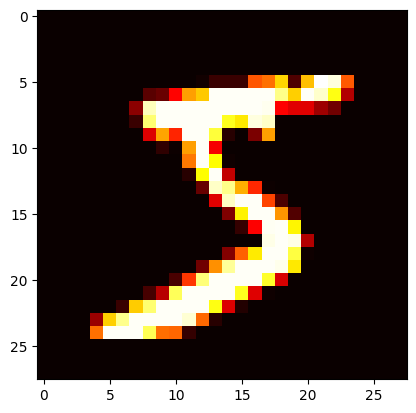

In [10]:
plt.imshow(X_train[0],cmap='hot')

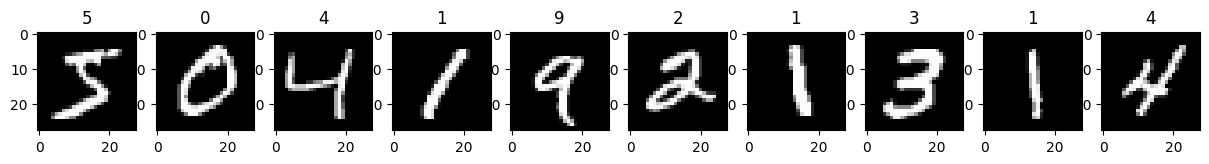

In [9]:
fig ,axes=plt.subplots(1,10,figsize=(15,3))
for i in range(10):
  axes[i].imshow(X_train[i],cmap='gray')
  axes[i].set_title(y_train[i])

In [11]:
print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())

Min pixel value: 0
Max pixel value: 255


In [12]:
X_train=X_train/255.0
X_test=X_test/255.0
print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())

Min pixel value: 0.0
Max pixel value: 1.0


In [13]:
X_train_flat= X_train.reshape(60000,-1)
X_test_flat= X_test.reshape(10000,-1)
print(X_train.shape)
print(X_train_flat.shape)


(60000, 28, 28)
(60000, 784)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model=LogisticRegression(max_iter=1000)
model.fit(X_train_flat,y_train)

predictions = model.predict(X_test_flat)
accuracy = accuracy_score(y_test, predictions)


In [15]:
print(f"accuracy: {accuracy*100}")

accuracy: 92.58999999999999


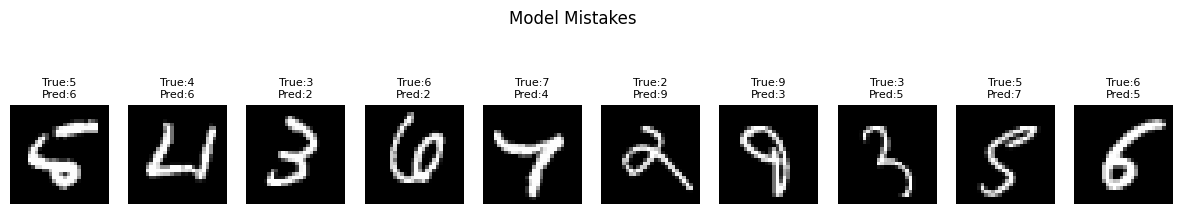

In [16]:
# Find images the model got WRONG
wrong_indices = np.where(predictions != y_test)[0]

# Plot 10 mistakes
fig, axes = plt.subplots(1, 10, figsize=(15, 3))

for i in range(10):
    idx = wrong_indices[i]
    axes[i].imshow(X_test[idx], cmap='gray')
    axes[i].set_title(f"True:{y_test[idx]}\nPred:{predictions[idx]}", fontsize=8)
    axes[i].axis('off')

plt.suptitle("Model Mistakes", fontsize=12)
plt.show()